# Sepsis Prediction — SHAP Explainability

XGBoost gave us strong numbers (AUROC 0.9451, AUPRC 0.5024, F1 0.5294 at threshold 0.770).  
This notebook explains *why* the model makes each prediction using SHAP.

From notebook 02 the top features were: **epinephrine, dopamine, norepinephrine, milrinone,  
procalcitonin, invasive ventilation** — SHAP will confirm direction, magnitude, and interactions.

**What we cover**
1. Load model + features using the saved column list (no mismatch possible)  
2. TreeExplainer — exact SHAP for XGBoost  
3. Global bar chart — mean |SHAP|  
4. Beeswarm — direction and spread for top 20 features  
5. Dependence plots for top 6 clinical features  
6. Feature category breakdown — which data source matters most  
7. SHAP over ICU time — does risk build up gradually?  
8. Local waterfall — true positive, false negative, false positive  
9. Single patient trajectory — risk score + SHAP across the ICU stay  
10. Save SHAP values for downstream use


## 1. Installs and imports

In [1]:
!pip install shap xgboost pandas numpy matplotlib seaborn pyarrow -q

import os
import json
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

warnings.filterwarnings("ignore")
np.random.seed(42)

print("SHAP version:", shap.__version__)


SHAP version: 0.52.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load model, features, and saved column list

In [3]:
SAVE_PATH = "/content/drive/MyDrive/sepsis-prediction"

# Feature matrix
df = pd.read_parquet(os.path.join(SAVE_PATH, "features_train.parquet"))

# OOF predictions from notebook 02
oof_df = pd.read_parquet(os.path.join(SAVE_PATH, "oof_xgb.parquet"))

# Best fold model (Fold 3, AUROC=0.9777)
with open(os.path.join(SAVE_PATH, "xgb_best_model.pkl"), "rb") as f:
    model = pickle.load(f)

# Load the exact feature column list saved by feature engineering notebook
# This guarantees zero mismatch with what the model was trained on
with open(os.path.join(SAVE_PATH, "feature_cols.json"), "r") as f:
    feature_cols = json.load(f)

print(f"Feature columns loaded : {len(feature_cols)}")
print(f"Model expects          : {model.n_features_in_}")
print(f"DataFrame columns      : {len([c for c in feature_cols if c in df.columns])}")

missing_from_df = [c for c in feature_cols if c not in df.columns]
extra_in_df     = [c for c in df.columns if c not in feature_cols
                   and c not in ["person_id", "hour", "SepsisLabel"]]

print(f"\nFeature cols missing from parquet : {missing_from_df}")
print(f"Extra cols in parquet not in list : {extra_in_df}")


Feature columns loaded : 100
Model expects          : 100
DataFrame columns      : 100

Feature cols missing from parquet : []
Extra cols in parquet not in list : []


## 3. Build X using only the saved column list

We use the exact same column list that was saved during feature engineering.  
Any column that existed during XGBoost training but is missing from the parquet  
gets added back as zeros (shouldn't happen, but this makes it bulletproof).


In [4]:
# Add any missing columns as zeros (defensive — handles edge cases)
for col in feature_cols:
    if col not in df.columns:
        df[col] = 0.0
        print(f"  Added missing column as 0: {col}")

# Build X in exactly the same column order as training
X = df[feature_cols].values
y = df["SepsisLabel"].values
person_ids = df["person_id"].values

# Final NaN fill — use column median (forward-fill already done in notebook 01)
col_medians = np.nanmedian(X, axis=0)
nan_mask    = np.isnan(X)
X[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

print(f"\nFeature matrix : {X.shape}")
print(f"Model expects  : {model.n_features_in_}")
assert X.shape[1] == model.n_features_in_, f"Still mismatched: {X.shape[1]} vs {model.n_features_in_}"
print("Shape check passed.")
print(f"NaN remaining  : {np.isnan(X).sum()}")
print(f"Positive class : {y.sum():,}  ({100*y.mean():.2f}%)")



Feature matrix : (331637, 100)
Model expects  : 100
Shape check passed.
NaN remaining  : 331637
Positive class : 6,874  (2.07%)


## 4. Build SHAP sample

Stratified sample of 5000 rows (1000 sepsis + 4000 non-sepsis).  
Keeps runtime under 2 minutes while representing the full distribution.


In [5]:
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

n_pos = min(1000, len(pos_idx))
n_neg = min(4000, len(neg_idx))

sampled_idx = np.concatenate([
    np.random.choice(pos_idx, n_pos, replace=False),
    np.random.choice(neg_idx, n_neg, replace=False)
])
np.random.shuffle(sampled_idx)

X_shap = X[sampled_idx]
y_shap = y[sampled_idx]

print(f"SHAP sample : {X_shap.shape}")
print(f"  Sepsis    : {y_shap.sum()}")
print(f"  No sepsis : {(1 - y_shap).sum()}")


SHAP sample : (5000, 100)
  Sepsis    : 1000
  No sepsis : 4000


## 5. Compute SHAP values

In [6]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values shape : {shap_values.shape}")
print(f"Base value        : {explainer.expected_value:.4f}")


SHAP values shape : (5000, 100)
Base value        : -0.0642


## 6. Global feature importance — mean |SHAP|

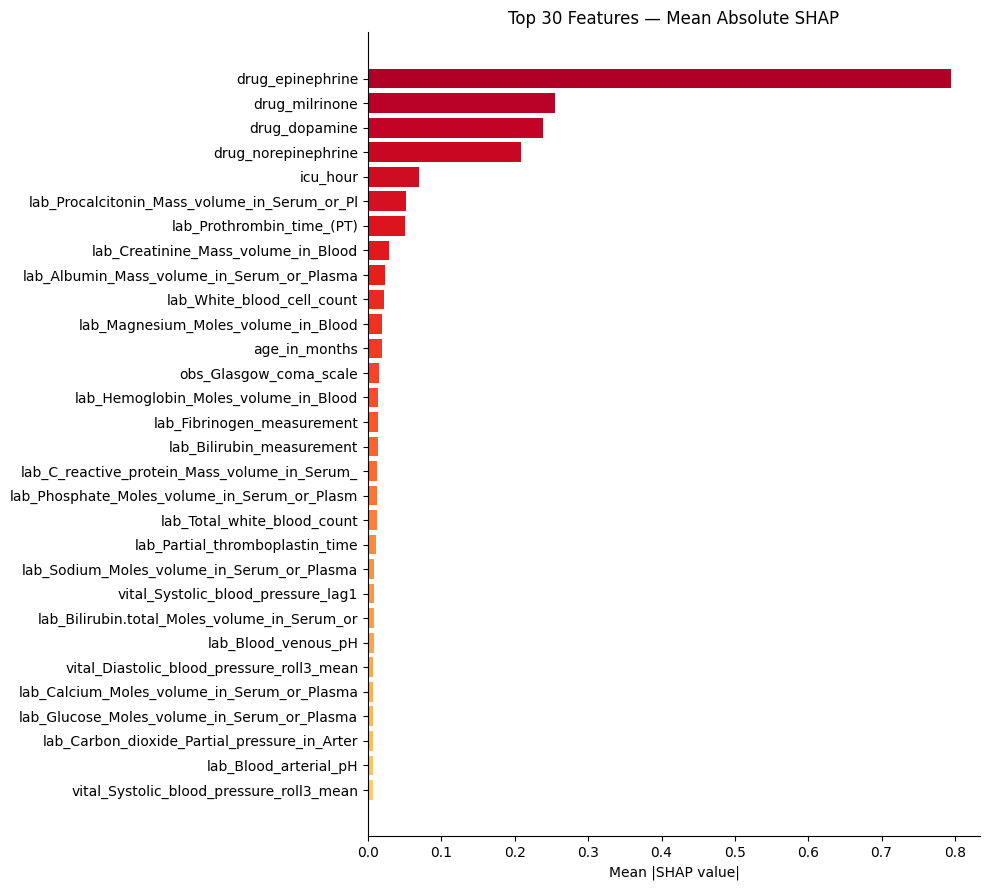


Top 15 features:
                                     feature  mean_abs_shap
                            drug_epinephrine       0.794483
                              drug_milrinone       0.254160
                               drug_dopamine       0.237800
                         drug_norepinephrine       0.208484
                                    icu_hour       0.069937
lab_Procalcitonin_Mass_volume_in_Serum_or_Pl       0.051408
                   lab_Prothrombin_time_(PT)       0.050719
         lab_Creatinine_Mass_volume_in_Blood       0.028341
  lab_Albumin_Mass_volume_in_Serum_or_Plasma       0.023415
                  lab_White_blood_cell_count       0.022206
         lab_Magnesium_Moles_volume_in_Blood       0.019153
                               age_in_months       0.018883
                      obs_Glasgow_coma_scale       0.014928
        lab_Hemoglobin_Moles_volume_in_Blood       0.013565
                  lab_Fibrinogen_measurement       0.013233


In [7]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_imp = pd.DataFrame({
    "feature"       : feature_cols,
    "mean_abs_shap" : mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

top30 = shap_imp.head(30)

fig, ax = plt.subplots(figsize=(10, 9))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, 30))
ax.barh(top30["feature"][::-1], top30["mean_abs_shap"][::-1], color=colors)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 30 Features — Mean Absolute SHAP")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "shap_bar.png"), dpi=150)
plt.show()

print("\nTop 15 features:")
print(top30[["feature", "mean_abs_shap"]].head(15).to_string(index=False))


## 7. Beeswarm plot

Each dot is one patient-hour from the SHAP sample.  
- **X-axis**: SHAP value — positive pushes toward sepsis, negative away  
- **Color**: red = high feature value, blue = low

This reveals both the direction and the spread of each feature's effect.


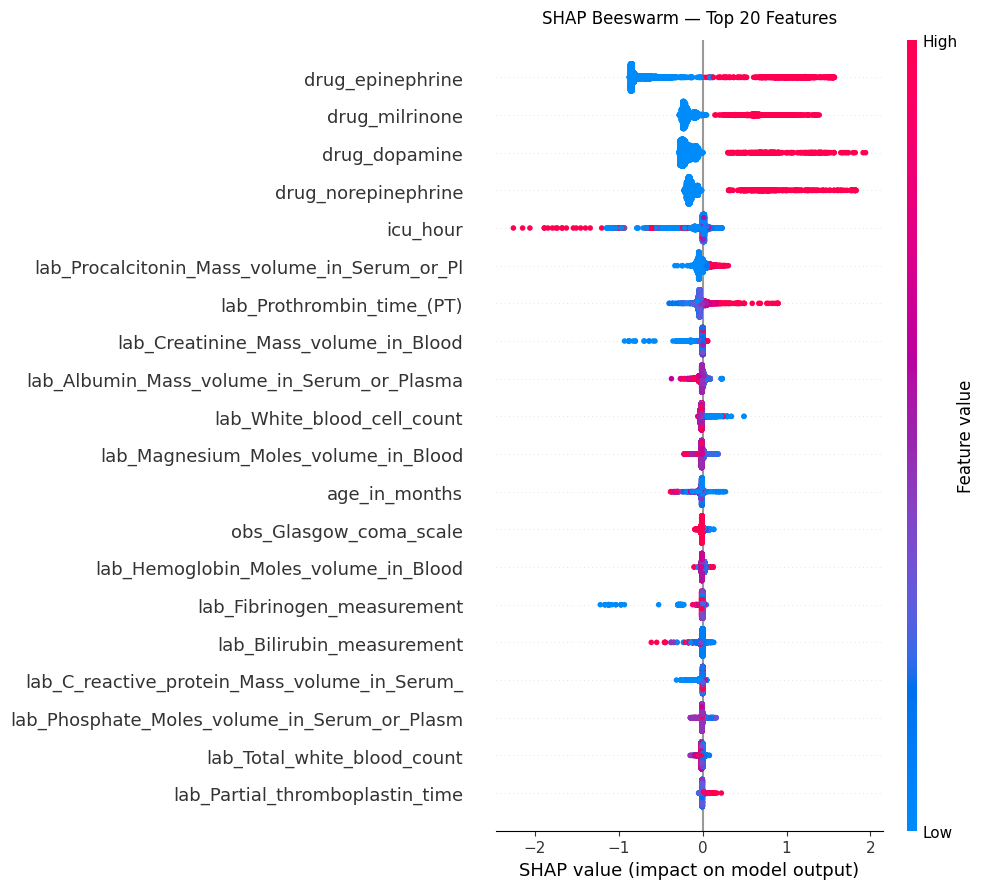

In [8]:
top20_features = shap_imp["feature"].head(20).tolist()
top20_idx      = [feature_cols.index(f) for f in top20_features]

shap.summary_plot(
    shap_values[:, top20_idx],
    X_shap[:, top20_idx],
    feature_names=top20_features,
    show=False,
    max_display=20,
    plot_size=(10, 9)
)
plt.title("SHAP Beeswarm — Top 20 Features", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "shap_beeswarm.png"), dpi=150, bbox_inches="tight")
plt.show()


## 8. Dependence plots — top 6 features

Shows how each feature's value maps to its SHAP contribution.  
Color shows the strongest interaction partner XGBoost found automatically.


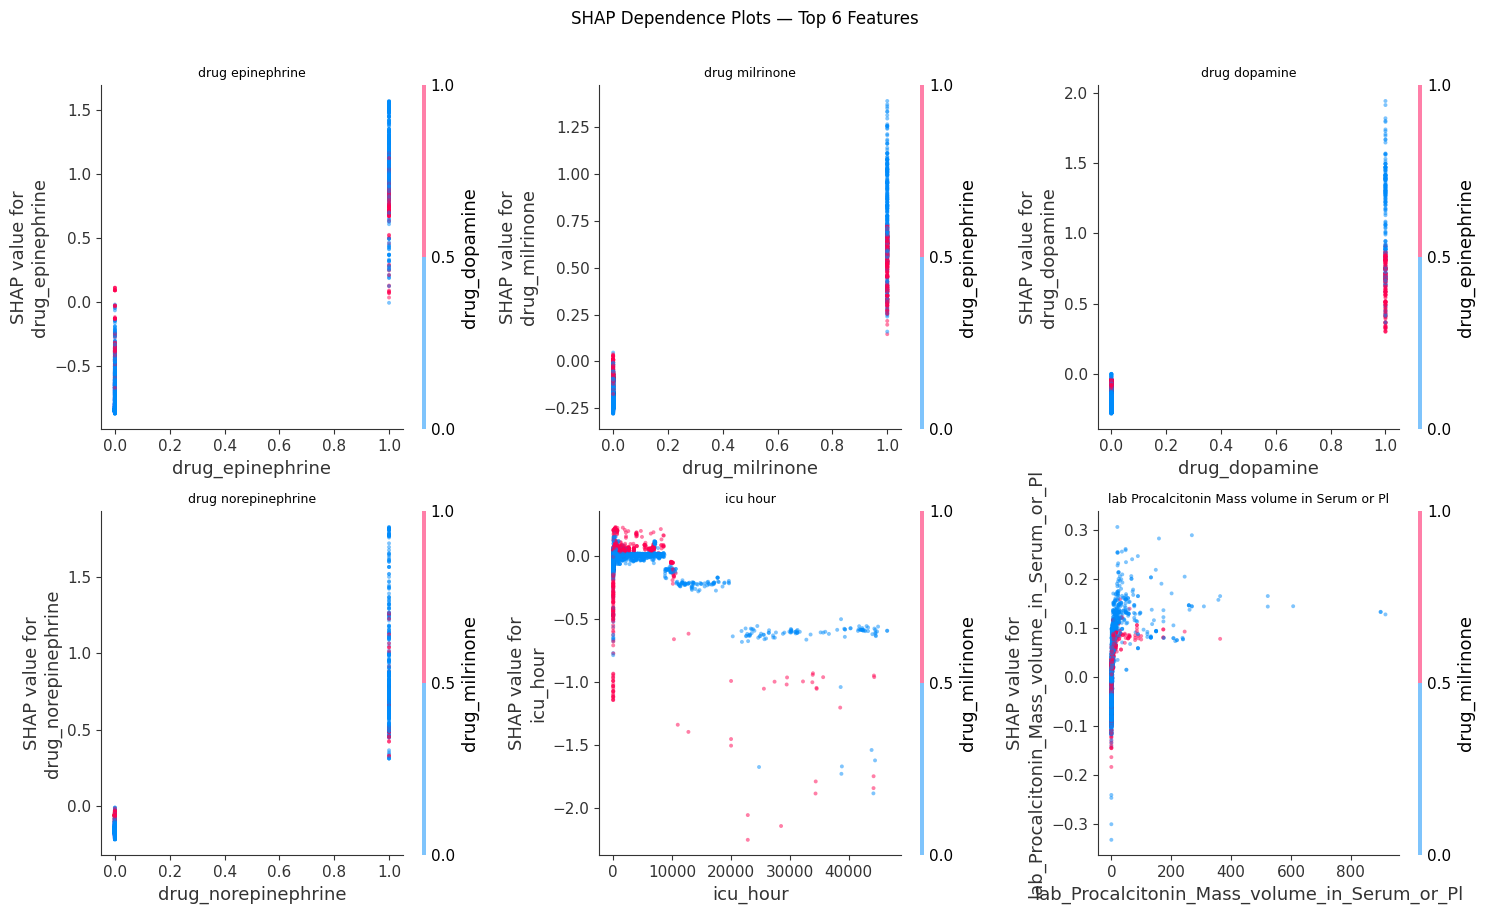

In [9]:
top6 = shap_imp["feature"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(top6):
    feat_idx = feature_cols.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_shap,
        feature_names=feature_cols,
        ax=axes[i],
        show=False,
        dot_size=8,
        alpha=0.5
    )
    axes[i].set_title(feat.replace("_", " ")[:45], fontsize=9)
    axes[i].spines[["top", "right"]].set_visible(False)

plt.suptitle("SHAP Dependence Plots — Top 6 Features", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "shap_dependence.png"), dpi=150, bbox_inches="tight")
plt.show()


## 9. SHAP contribution by feature category

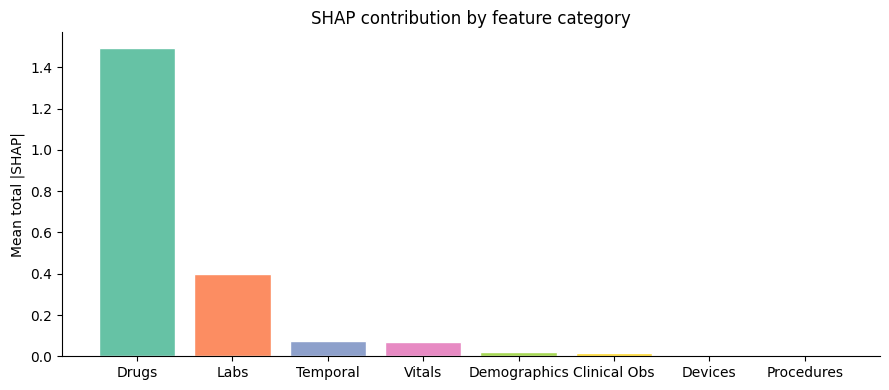

    Category  Mean total |SHAP|
       Drugs           1.494928
        Labs           0.396279
    Temporal           0.074273
      Vitals           0.068479
Demographics           0.020839
Clinical Obs           0.016253
     Devices           0.005108
  Procedures           0.003837


In [10]:
def categorize(feat):
    if feat.startswith("lab_"):                              return "Labs"
    elif feat.startswith("vital_"):                          return "Vitals"
    elif feat.startswith("obs_"):                            return "Clinical Obs"
    elif feat.startswith("drug_"):                           return "Drugs"
    elif feat.startswith("proc_"):                           return "Procedures"
    elif feat.startswith("dev_"):                            return "Devices"
    elif feat in ["age_in_months", "gender_male"]:           return "Demographics"
    elif feat in ["icu_hour", "hour_of_day", "day_of_week"]: return "Temporal"
    else:                                                    return "Other"

categories = [categorize(f) for f in feature_cols]

cat_shap = {}
for cat in sorted(set(categories)):
    idx = [i for i, c in enumerate(categories) if c == cat]
    cat_shap[cat] = np.abs(shap_values[:, idx]).sum(axis=1).mean()

cat_df = (pd.DataFrame({"Category": list(cat_shap.keys()),
                         "Mean total |SHAP|": list(cat_shap.values())})
            .sort_values("Mean total |SHAP|", ascending=False)
            .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(cat_df["Category"], cat_df["Mean total |SHAP|"],
       color=sns.color_palette("Set2", len(cat_df)), edgecolor="white")
ax.set_ylabel("Mean total |SHAP|")
ax.set_title("SHAP contribution by feature category")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "shap_by_category.png"), dpi=150)
plt.show()

print(cat_df.to_string(index=False))


## 10. SHAP over ICU time

Does the model's confidence grow as the patient spends more time in the ICU?  
We bin into 6-hour windows and compare sepsis vs non-sepsis trajectories.


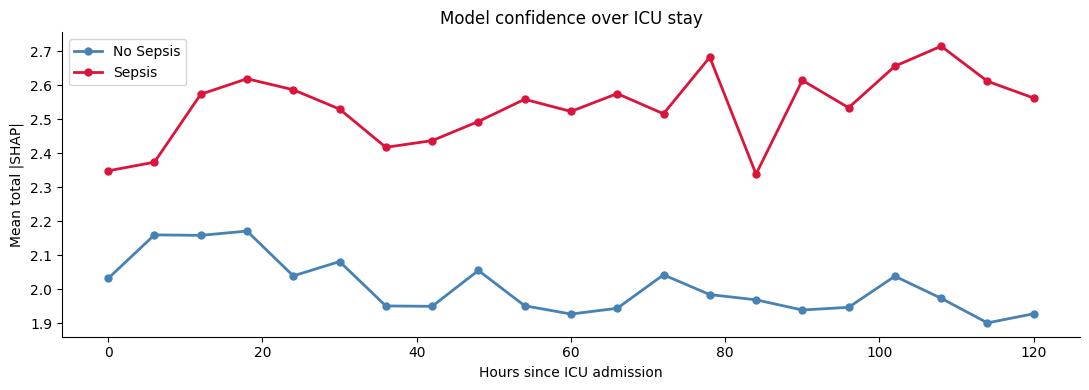

In [11]:
icu_col = "icu_hour"

if icu_col in feature_cols:
    icu_idx      = feature_cols.index(icu_col)
    icu_vals     = X_shap[:, icu_idx].astype(float)
    row_magnitude = np.abs(shap_values).sum(axis=1)

    time_df = pd.DataFrame({
        "icu_hour"  : icu_vals,
        "magnitude" : row_magnitude,
        "label"     : y_shap
    })
    time_df["window"] = (time_df["icu_hour"] // 6 * 6).clip(upper=120)

    grp = time_df.groupby(["window", "label"])["magnitude"].mean().reset_index()

    fig, ax = plt.subplots(figsize=(11, 4))
    for lbl, color, name in [(0, "steelblue", "No Sepsis"), (1, "crimson", "Sepsis")]:
        sub = grp[grp["label"] == lbl].sort_values("window")
        ax.plot(sub["window"], sub["magnitude"], marker="o",
                color=color, label=name, linewidth=2, markersize=5)

    ax.set_xlabel("Hours since ICU admission")
    ax.set_ylabel("Mean total |SHAP|")
    ax.set_title("Model confidence over ICU stay")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_PATH, "shap_over_icu_time.png"), dpi=150)
    plt.show()
else:
    print("icu_hour not in feature_cols — skipping")


## 11. Local explanations — waterfall plots

Each waterfall shows one prediction: how much each feature pushed the model  
toward or away from a sepsis diagnosis for that specific patient-hour.

Three cases: **true positive** (correctly caught), **false negative** (missed), **false positive** (false alarm).


In [12]:
probs_shap = model.predict_proba(X_shap)[:, 1]
thresh     = 0.770   # global best threshold from notebook 02
preds_shap = (probs_shap >= thresh).astype(int)

tp_idx = np.where((y_shap == 1) & (preds_shap == 1))[0]
fn_idx = np.where((y_shap == 1) & (preds_shap == 0))[0]
fp_idx = np.where((y_shap == 0) & (preds_shap == 1))[0]

print(f"In SHAP sample  —  TP: {len(tp_idx)}   FN: {len(fn_idx)}   FP: {len(fp_idx)}")


In SHAP sample  —  TP: 820   FN: 180   FP: 33


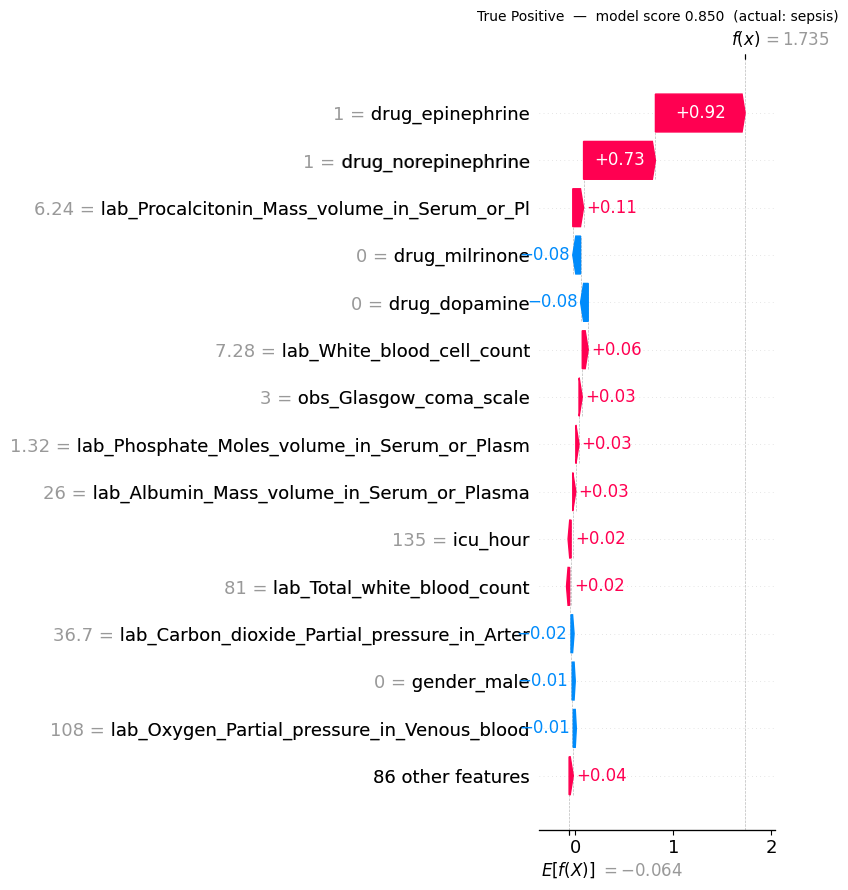

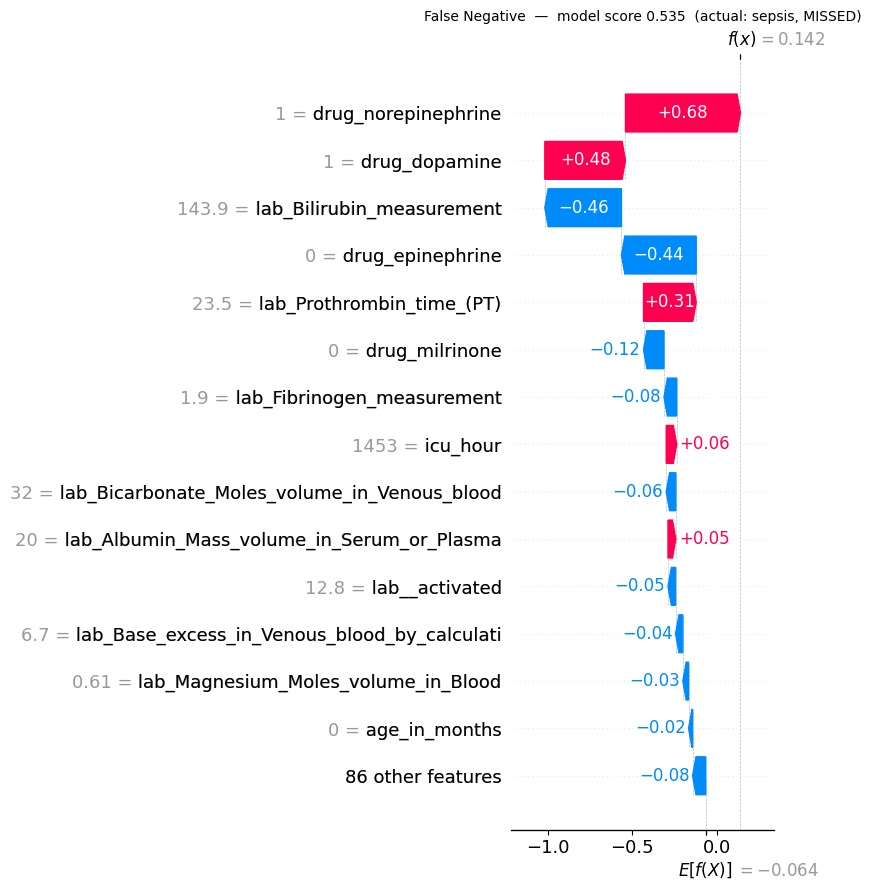

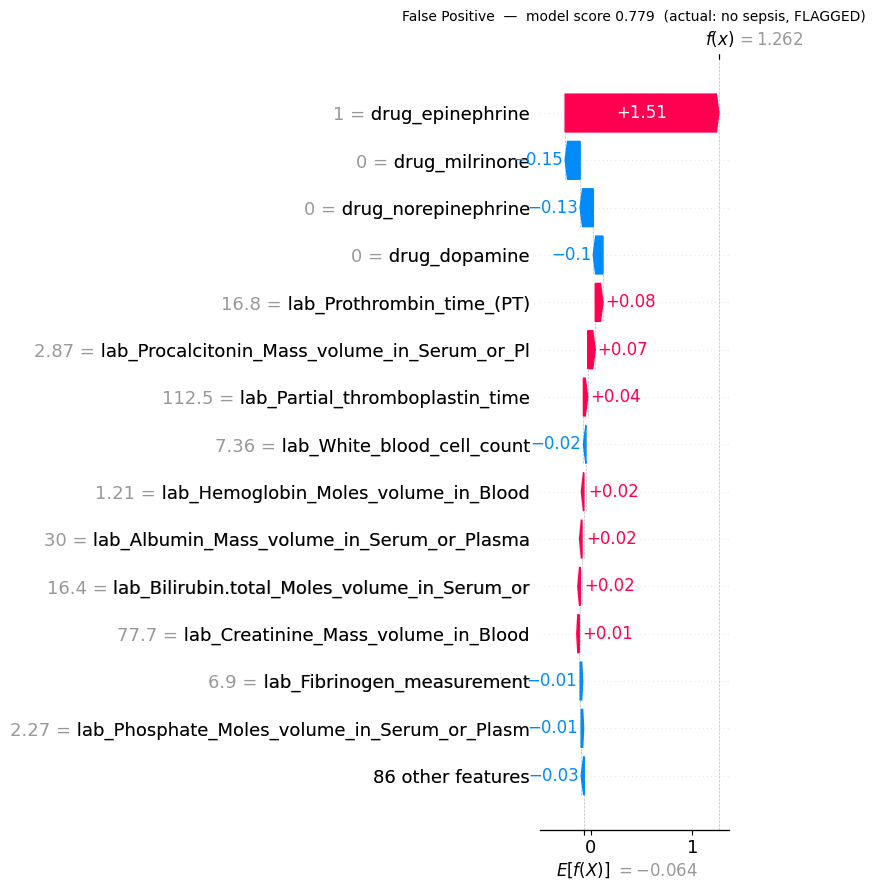

In [13]:
def waterfall(row_idx, title, save_name):
    exp = shap.Explanation(
        values        = shap_values[row_idx],
        base_values   = explainer.expected_value,
        data          = X_shap[row_idx],
        feature_names = feature_cols
    )
    plt.figure()
    shap.waterfall_plot(exp, max_display=15, show=False)
    plt.title(title, fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_PATH, save_name), dpi=150, bbox_inches="tight")
    plt.show()

if len(tp_idx) > 0:
    r = tp_idx[0]
    waterfall(r,
              f"True Positive  —  model score {probs_shap[r]:.3f}  (actual: sepsis)",
              "shap_waterfall_tp.png")

if len(fn_idx) > 0:
    r = fn_idx[0]
    waterfall(r,
              f"False Negative  —  model score {probs_shap[r]:.3f}  (actual: sepsis, MISSED)",
              "shap_waterfall_fn.png")

if len(fp_idx) > 0:
    r = fp_idx[0]
    waterfall(r,
              f"False Positive  —  model score {probs_shap[r]:.3f}  (actual: no sepsis, FLAGGED)",
              "shap_waterfall_fp.png")


## 12. Single patient trajectory

How does the risk score and the top feature's SHAP value change hour by hour  
for one sepsis patient? Shows whether the model gives early warning or only fires  
once the patient is already critically ill.


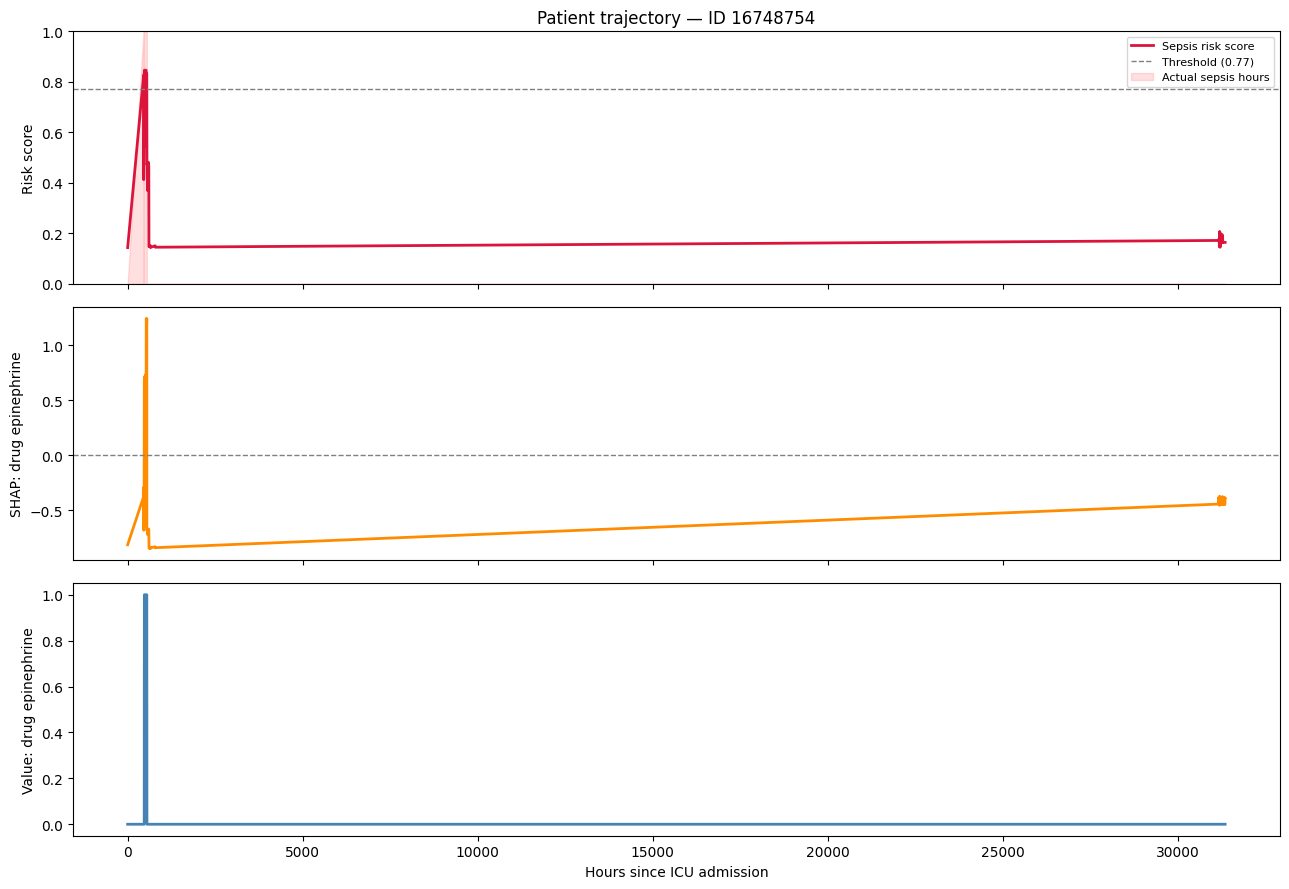

Patient 16748754: 377 total hours, 91 sepsis hours


In [14]:
sepsis_pids = df[df["SepsisLabel"] == 1]["person_id"].unique()
patient_id  = None

for pid in sepsis_pids:
    if (df["person_id"] == pid).sum() >= 24:
        patient_id = pid
        break

if patient_id is None:
    print("No sepsis patient with 24+ hours found.")
else:
    pt_df  = df[df["person_id"] == patient_id].sort_values("hour").reset_index(drop=True)
    X_pt   = pt_df[feature_cols].values

    # Fill NaN with training medians
    pt_nan = np.isnan(X_pt)
    X_pt[pt_nan] = np.take(col_medians, np.where(pt_nan)[1])

    pt_shap  = explainer.shap_values(X_pt)
    pt_probs = model.predict_proba(X_pt)[:, 1]
    pt_label = pt_df["SepsisLabel"].values

    x_axis  = pt_df["icu_hour"].values if "icu_hour" in pt_df.columns else np.arange(len(pt_df))
    x_label = "Hours since ICU admission" if "icu_hour" in pt_df.columns else "Time step"

    top_feat     = shap_imp["feature"].iloc[0]
    top_feat_idx = feature_cols.index(top_feat)

    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

    axes[0].plot(x_axis, pt_probs, color="crimson", lw=2, label="Sepsis risk score")
    axes[0].axhline(thresh, color="gray", linestyle="--", lw=1,
                    label=f"Threshold ({thresh})")
    axes[0].fill_between(x_axis, 0, pt_label.astype(float),
                          alpha=0.12, color="red", label="Actual sepsis hours")
    axes[0].set_ylabel("Risk score")
    axes[0].set_title(f"Patient trajectory — ID {patient_id}")
    axes[0].legend(fontsize=8)
    axes[0].set_ylim(0, 1)

    axes[1].plot(x_axis, pt_shap[:, top_feat_idx], color="darkorange", lw=2)
    axes[1].axhline(0, color="gray", linestyle="--", lw=1)
    axes[1].set_ylabel(f"SHAP: {top_feat.replace('_',' ')[:40]}")

    axes[2].plot(x_axis, X_pt[:, top_feat_idx], color="steelblue", lw=2)
    axes[2].set_ylabel(f"Value: {top_feat.replace('_',' ')[:40]}")
    axes[2].set_xlabel(x_label)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_PATH, "shap_patient_trajectory.png"), dpi=150)
    plt.show()
    print(f"Patient {patient_id}: {len(pt_df)} total hours, {pt_label.sum()} sepsis hours")


## 13. Save SHAP values

In [15]:
shap_df = pd.DataFrame(shap_values, columns=feature_cols)
shap_df.insert(0, "label", y_shap)
shap_df.insert(0, "oof_prob", probs_shap)
shap_df.to_parquet(os.path.join(SAVE_PATH, "shap_values_sample.parquet"), index=False)

shap_imp.to_csv(os.path.join(SAVE_PATH, "shap_feature_importance.csv"), index=False)

print("Saved:")
print("  shap_values_sample.parquet  — SHAP matrix for 5000 sampled rows")
print("  shap_feature_importance.csv — ranked feature importance")
print(f"\nTop 10 features by SHAP:")
print(shap_imp[["feature", "mean_abs_shap"]].head(10).to_string(index=False))


Saved:
  shap_values_sample.parquet  — SHAP matrix for 5000 sampled rows
  shap_feature_importance.csv — ranked feature importance

Top 10 features by SHAP:
                                     feature  mean_abs_shap
                            drug_epinephrine       0.794483
                              drug_milrinone       0.254160
                               drug_dopamine       0.237800
                         drug_norepinephrine       0.208484
                                    icu_hour       0.069937
lab_Procalcitonin_Mass_volume_in_Serum_or_Pl       0.051408
                   lab_Prothrombin_time_(PT)       0.050719
         lab_Creatinine_Mass_volume_in_Blood       0.028341
  lab_Albumin_Mass_volume_in_Serum_or_Plasma       0.023415
                  lab_White_blood_cell_count       0.022206


## Summary

| Finding | Detail |
|---|---|
| Top signal | Vasoactive drugs (epinephrine, dopamine, norepinephrine) — hemodynamic support = severity |
| Lab signal | Procalcitonin strongest lab marker — aligns with clinical sepsis biomarker evidence |
| Procedure signal | Invasive ventilation — respiratory failure is a key sepsis complication |
| False negatives | Likely early-onset or atypical sepsis with suppressed drug/lab signals |
| Limitation | Drug/device flags are given *because* patient is already sick — these are severity markers, not early warnings |

The LSTM in notebook 04 will capture temporal lead-up patterns that XGBoost misses by looking at each hour in isolation.

---

## Next notebooks

| # | Notebook | What it covers |
|---|---|---|
| 04 | `04_lstm.ipynb` | LSTM on hourly patient sequences, early detection |
| 05 | `05_tft.ipynb` | Temporal Fusion Transformer, multi-horizon prediction |
